In [1]:
import os
import pickle
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')

import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')
figDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'figures')
# tmpFigDir = os.path.join('/Users', getpass.getuser(), 'Dropbox (Personal)', 'bmw1_Manuscript', 'figures', 'plots')


## structured vs non-structured components

First we need to establish whether we wanna use structured components or non-structured ones for the decomposition. Here we test the performance of non-structured vs structured models.

Based on the CKA results here, generally, the CKA did improved in all cases except for PMv and SMA which actually reduced. The improvement failed to become significant except in V1. So my conclusion is it's a good idea to include the structure in variance decoposition method.

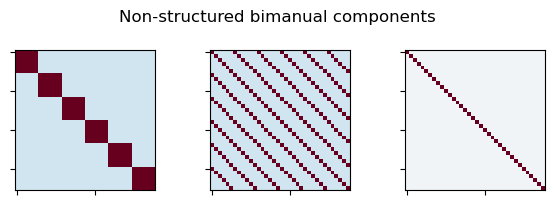

fitting M1


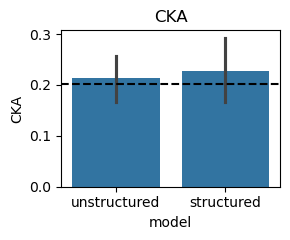

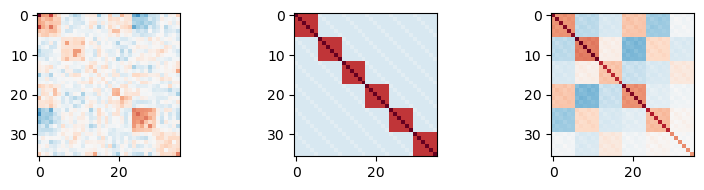

fitting S1


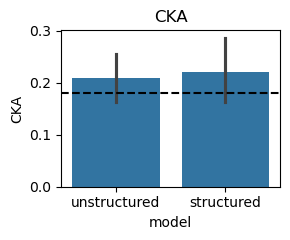

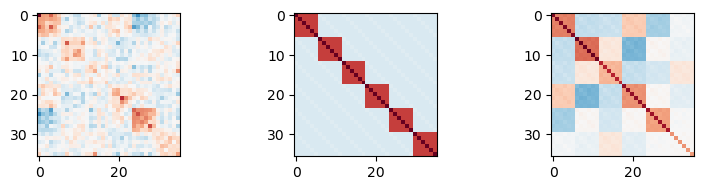

fitting PMd


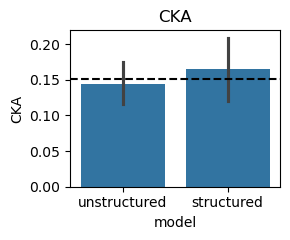

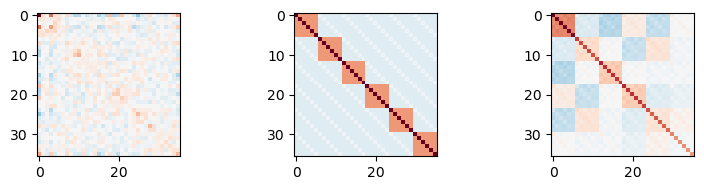

fitting PMv


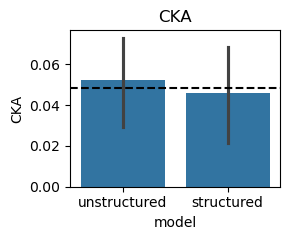

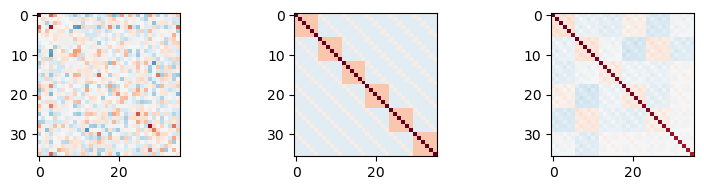

fitting SMA


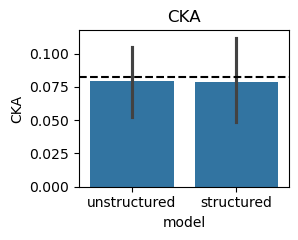

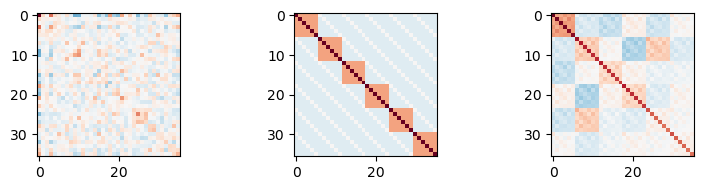

fitting SPLa


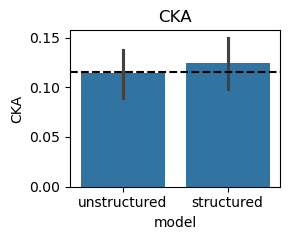

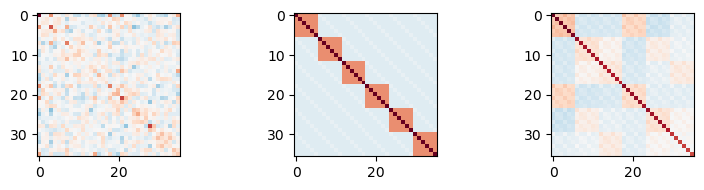

fitting SPLp


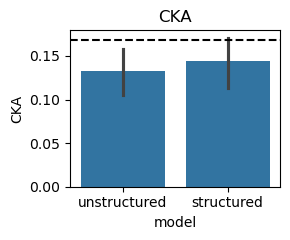

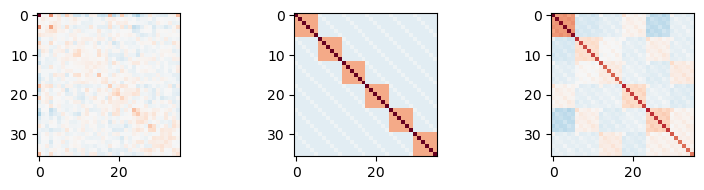

fitting V1


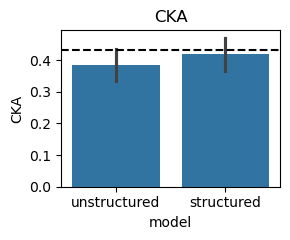

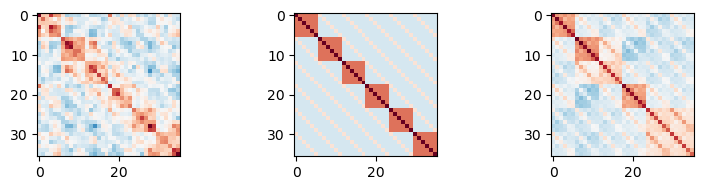

  region  dof    t_stat     p_val
0     M1   23  0.775087  0.446185
1     S1   23  0.857837  0.399834
2    PMd   23  1.733837  0.096334
3    PMv   23 -1.133474  0.268693
4    SMA   23 -0.050374  0.960260
5   SPLa   23  1.776033  0.088961
6   SPLp   23  1.772464  0.089565
7     V1   23  4.133856  0.000403


In [2]:
# load non-sturctured components:
G_nonstructured = utils.models.non_structured_bimanual_components(verbose=True)

regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

T_group = []
theta_group = []
ceil_group = []
df_stats = {'region':[], 'dof':[], 't_stat':[], 'p_val':[]}
for region in regions:
    G_structured = utils.models.structured_bimanual_components(region=region, verbose=False)

    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    D = D['Y'].tolist()

    # estimate data G_est:
    G_est = np.zeros((len(D), ncond, ncond))
    for i in range(len(D)):
        G_est[i,:,:],_ =  pcm.est_G_crossval(D[i].measurements,
                                            D[i].obs_descriptors['cond_vec'],
                                            D[i].obs_descriptors['part_vec'],
                                            X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
    G_mean = np.mean(G_est, axis=0)

    M = []
    # non-structured:   
    M.append(pcm.ComponentModel('unstructured', [G_nonstructured['contra'],G_nonstructured['ipsi'], G_nonstructured['interaction']]))
    # structured:
    M.append(pcm.ComponentModel('structured', [G_structured['contra'],G_structured['ipsi'], G_structured['interaction']]))

    # fit group cross-validated:
    print(f'fitting {region}')
    T, theta, ceil = pcm.inference_cka.fit_CKA_group_crossval(D, M, verbose=False, ceil=True)

    # barplot CKA:
    CKA = T['CKA']
    ceil_low = np.mean(ceil['ceil_low'], axis=0)
    CKA_flat = CKA.melt(var_name='model', value_name='CKA')
    fig, ax = plt.subplots(figsize=(3, 2.5))
    sns.barplot(x='model', y='CKA', data=CKA_flat, ax=ax)
    ax.axhline(ceil_low, color='k', linestyle='--')
    ax.set_title('CKA')
    plt.tight_layout()
    plt.show()

    _, theta_gr = pcm.inference_cka.fit_CKA_group(D, M, verbose=False)
    # predicted G:
    fig, ax = plt.subplots(1, 3, figsize=(8, 2))
    vmax = np.max(np.abs(G_mean))
    vmin = -vmax
    ax[0].imshow(G_mean, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    for i in range(len(M)):
        G_pred, _= M[i].predict(theta_gr[i][:M[i].n_param])
        vmax = np.max(np.abs(G_pred))
        vmin = -vmax
        ax[i+1].imshow(G_pred, cmap='RdBu_r', vmin=vmin, vmax=vmax)
        
    plt.tight_layout()
    plt.show()

    # t-test between structured and non-structured model performance:
    CKA = T['CKA']
    t_stat, p_val = stats.ttest_rel(CKA['structured'], CKA['unstructured'], alternative='two-sided')
    
    df_stats['region'].append(region)
    df_stats['dof'].append(len(D)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

df_stats = pd.DataFrame(df_stats)
print(df_stats.to_string())



## cross-validated, variance decomposition

Here we decompose the bimanual structure into contra, ipsi, and interaction terms. The first two components include the structure derived from the unimanual data. The interaction term is a simple identity. Interaction is not orthogonalized to the other two because the goal is to compete over the variance in a cross-validated manner.

Here we test whether cross-validated CKA and model family can help us make an inference.

From the resutls here we infer that in most regions the ipsilateral compnent does not add any meaningful improvement. The interaction term however, very strongly improves the model performance.

fitting M1


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


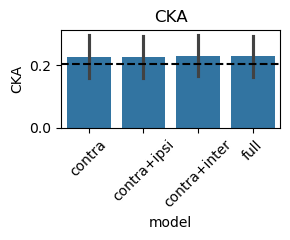

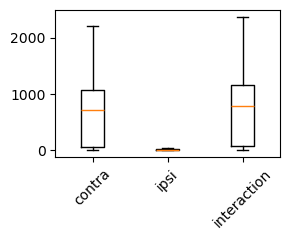

fitting S1


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


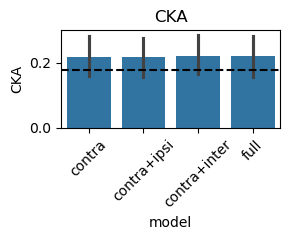

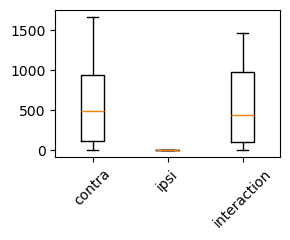

fitting PMd


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


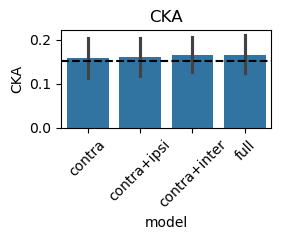

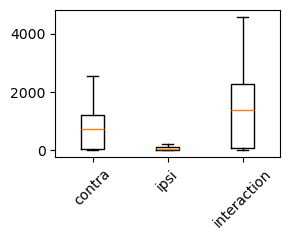

fitting PMv


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


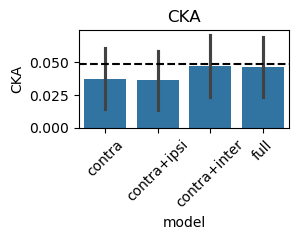

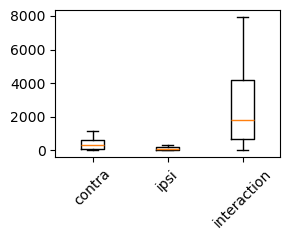

fitting SMA


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


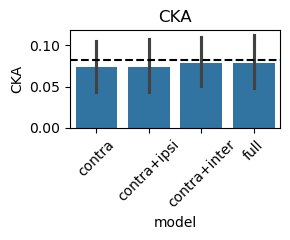

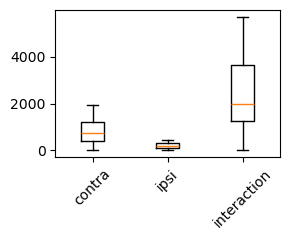

fitting SPLa


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


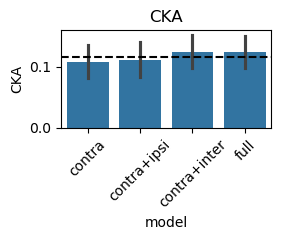

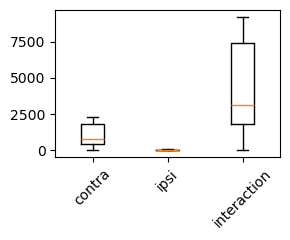

fitting SPLp


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


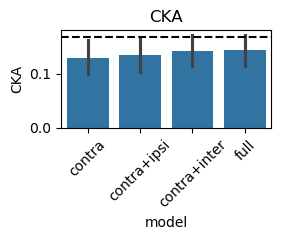

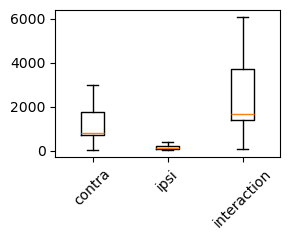

fitting V1


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_83080/3652098575.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


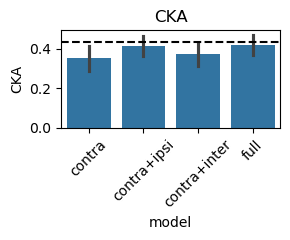

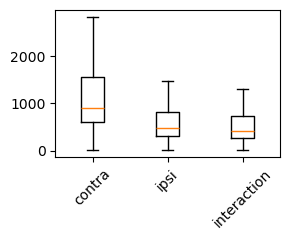

   region                   test  dof    t_stat     p_val
0      M1   contra+ipsi > contra   23  0.553720  0.292557
1      M1  contra+inter > contra   23  2.006148  0.028370
2      M1     full > contra+ipsi   23  1.925631  0.033301
3      M1    full > contra+inter   23 -1.311240  0.898641
4      S1   contra+ipsi > contra   23 -0.234949  0.591836
5      S1  contra+inter > contra   23  2.168570  0.020352
6      S1     full > contra+ipsi   23  2.186548  0.019604
7      S1    full > contra+inter   23 -2.142777  0.978529
8     PMd   contra+ipsi > contra   23  1.384483  0.089748
9     PMd  contra+inter > contra   23  2.558442  0.008783
10    PMd     full > contra+ipsi   23  1.994366  0.029049
11    PMd    full > contra+inter   23  0.369661  0.357509
12    PMv   contra+ipsi > contra   23 -0.059273  0.523377
13    PMv  contra+inter > contra   23  1.425476  0.083725
14    PMv     full > contra+ipsi   23  1.514522  0.071758
15    PMv    full > contra+inter   23 -1.071418  0.852452
16    SMA   co

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

df_stats = {'region':[], 'test':[], 'dof':[], 't_stat':[], 'p_val':[]}
for region in regions:
    G_structured = utils.models.structured_bimanual_components(region=region, verbose=False)

    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    D = D['Y'].tolist()

    M = []
    # contra-only model:
    M.append(pcm.ComponentModel('contra', [G_structured['contra']]))
    # contra+ipsi model:
    M.append(pcm.ComponentModel('contra+ipsi', [G_structured['contra'],G_structured['ipsi']]))
    # contra+interaction model:
    M.append(pcm.ComponentModel('contra+inter', [G_structured['contra'],G_structured['interaction']]))
    # full model:
    M.append(pcm.ComponentModel('full', [G_structured['contra'],G_structured['ipsi'], G_structured['interaction']]))

    # fit CKA group cross-validated:
    print(f'fitting {region}')
    T, theta, ceil = pcm.inference_cka.fit_CKA_group_crossval(D, M, verbose=False, ceil=True)

    # boxplot:
    CKA = T['CKA']
    ceil_low = np.mean(ceil['ceil_low'], axis=0)
    CKA_flat = CKA.melt(var_name='model', value_name='CKA')
    fig, ax = plt.subplots(figsize=(3, 2.5))
    sns.barplot(x='model', y='CKA', data=CKA_flat, ax=ax)
    ax.axhline(ceil_low, color='k', linestyle='--')
    ax.set_title('CKA')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()
    
    # boxplot, components of the full model:
    theta_full = np.exp(theta[-1])
    contra_th = theta_full[0,:]
    ipsi_th = theta_full[1,:]
    inter_th = theta_full[2,:]
    fig, ax = plt.subplots(figsize=(3, 2.5))
    # no fliers:
    ax.boxplot([contra_th, ipsi_th, inter_th], showfliers=False)
    ax.set_xticklabels(['contra', 'ipsi', 'interaction'], rotation=45)
    plt.tight_layout()
    plt.show()

    # stats:
    CKA = T['CKA']
    t_stat, p_val = stats.ttest_rel(CKA['contra+ipsi'], CKA['contra'], alternative='greater')
    df_stats['region'].append(region)
    df_stats['dof'].append(len(D)-1)
    df_stats['test'].append('contra+ipsi > contra')
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    t_stat, p_val = stats.ttest_rel(CKA['contra+inter'], CKA['contra'], alternative='greater')
    df_stats['region'].append(region)
    df_stats['test'].append('contra+inter > contra')
    df_stats['dof'].append(len(D)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    t_stat, p_val = stats.ttest_rel(CKA['full'], CKA['contra+ipsi'], alternative='greater')
    df_stats['region'].append(region)
    df_stats['test'].append('full > contra+ipsi')
    df_stats['dof'].append(len(D)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    t_stat, p_val = stats.ttest_rel(CKA['full'], CKA['contra+inter'], alternative='greater')
    df_stats['region'].append(region)
    df_stats['test'].append('full > contra+inter')
    df_stats['dof'].append(len(D)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

df_stats = pd.DataFrame(df_stats)
print(df_stats.to_string())



## OLS individual, weight of each component

Here I wanna answer how the weight of contra and ipsi components of bimanual changes compared to the unimanual activity patterns. For that, I fit a CKA full model (contra + ipsi + interaction) to each individual. I measure the variance associated with each component. 

But I can't use CKA. Because CKA weights are positively biased. Also, CKA does not find the actual value of the variance, rather it finds the proportional weight of the components such that the CKA is maximized.

So I will use a simple OLS. For each individual I will fit the three components to the data covariance matrix. Then I will use those weights to derive the variance of each component.

In [3]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

df_components = {'region':[], 'component':[], 'variance':[], 'd2':[], 'd':[]}
for region in regions:
    G_structured = utils.models.structured_bimanual_components(region=region, verbose=False)
    
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    D = D['Y'].tolist()
    
    # ================================ fit OLS individual ================================
    # estimate G_hat:
    G_hat = np.zeros((len(D), ncond, ncond))
    for i in range(len(D)):
        G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                                D[i].obs_descriptors['cond_vec'],
                                                D[i].obs_descriptors['part_vec'],
                                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
    # fit OLS on unique elements (G_hat is symmetric):
    # mask = np.triu(np.ones((ncond, ncond), dtype=bool))
    X = np.vstack([
        G_structured['contra'].flatten(),
        G_structured['ipsi'].flatten(),
        G_structured['interaction'].flatten(),
    ]).T
    pinvX = np.linalg.pinv(X)
    W = np.array([pinvX @ G_hat[i].flatten() for i in range(len(D))])

    # ================================ estimate variance ================================
    # OLS variances:
    ols_contra = W[:,0] * np.trace(G_structured['contra'])/ncond
    ols_ipsi = W[:,1] * np.trace(G_structured['ipsi'])/ncond
    ols_interaction = W[:,2] * np.trace(G_structured['interaction'])/ncond

    component_vars = [ols_contra, ols_ipsi, ols_interaction]
    component_names = ['contra', 'ipsi', 'interaction']
    for i, var in enumerate(component_vars):
        df_components['region'].extend([region]*len(var))
        df_components['component'].extend([component_names[i]]*len(var))
        df_components['variance'].extend(var)
        # d2 = 2/(K-1) * trace(G_hat):
        tmp_d2 = 2/(ncond-1) * var*ncond
        df_components['d2'].extend(tmp_d2)
        df_components['d'].extend(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))

df_components = pd.DataFrame(df_components)
# save:
df_components.to_csv(os.path.join(analysisDir, 'bimanual_OLS_decompose.csv'), index=False)



#### plot

ipsi: 0.000238
contra: 0.001866
interaction: 0.002515
interaction/contra: 1.347557


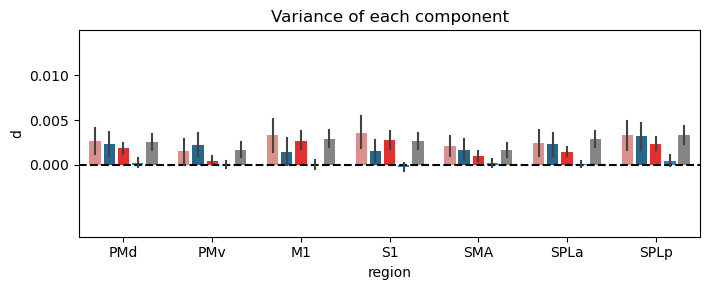

In [19]:
# load:
df_uni = pd.read_csv(os.path.join(analysisDir, 'unimanual_distances.csv'))
df_components = pd.read_csv(os.path.join(analysisDir, 'bimanual_OLS_decompose.csv'))

# add uni_contra and uni_ipsi to df_components:
df_uni['component'] = df_uni['component'].replace({'contra': 'uni_contra', 'ipsi': 'uni_ipsi'})
df_components = pd.concat([df_components, df_uni], ignore_index=True)

# remove v1:
df_components = df_components[df_components['region'] != 'V1']

test_reg = 'PMd'
row1 = (df_components['region'] == test_reg) & (df_components['component'] == 'ipsi')
row2 = (df_components['region'] == test_reg) & (df_components['component'] == 'contra')
row3 = (df_components['region'] == test_reg) & (df_components['component'] == 'interaction')
print(f'ipsi: {np.mean(df_components.loc[row1, "d"].values):.6f}')
print(f'contra: {np.mean(df_components.loc[row2, "d"].values):.6f}')
print(f'interaction: {np.mean(df_components.loc[row3, "d"].values):.6f}')
print(f'interaction/contra: {np.mean(df_components.loc[row3, "d"].values)/np.mean(df_components.loc[row2, "d"].values):.6f}')

# boxplot:
fig, ax = plt.subplots(figsize=(7.2, 3))
ax.axhline(0, color='k', linestyle='--')
# sns.boxplot(x='region', y='d', hue='component', data=df_components, ax=ax, 
#             legend=False, showfliers=False, width=0.8, gap=0.2, linewidth=1.5,
#             hue_order=['uni_contra', 'uni_ipsi', 'contra', 'ipsi', 'interaction'],
#             order=['PMd','PMv','M1','S1','SMA','SPLa','SPLp'],
#             palette=['#E7857E','#166C9C','#FF130F', '#0086F0', '#858585'], fill=True)
# bar plot:
sns.barplot(x='region', y='d', hue='component', data=df_components, ax=ax, 
            legend=False, width=0.8, gap=0.2, err_kws={'linewidth': 1.5},
            hue_order=['uni_contra', 'uni_ipsi', 'contra', 'ipsi', 'interaction'],
            order=['PMd','PMv','M1','S1','SMA','SPLa','SPLp'],
            palette=['#E7857E','#166C9C','#FF130F', '#0086F0', '#858585'], fill=True)
ax.set_title('Variance of each component')
plt.ylim((-0.008,0.015))
plt.yticks([0, 0.005, 0.01])
plt.tight_layout()
# savefig:
plt.savefig(os.path.join(figDir, 'bimanual_OLS_decompose.pdf'), bbox_inches="tight")
plt.show()



#### stats component > 0

In [12]:
df_components = pd.read_csv(os.path.join(analysisDir, 'bimanual_OLS_decompose.csv'))
# remove v1:
df_components = df_components[df_components['region'] != 'V1']

regions = df_components['region'].unique()

component_names = ['contra', 'ipsi', 'interaction']
df_stats = {'region':[], 'component':[], 'dof':[], 't_stat':[], 'p_unc':[]}
for region in regions:
    for component in component_names:
        df_component = df_components[df_components['region'] == region]
        df_component = df_component[df_component['component'] == component]
        
        # t-test > 0:
        t_stat, p_val = stats.ttest_1samp(df_component['d'], 0, alternative='greater')
        df_stats['region'].append(region)
        df_stats['component'].append(component)
        df_stats['dof'].append(len(df_component)-1)
        df_stats['t_stat'].append(t_stat)
        df_stats['p_unc'].append(p_val)

df_stats = pd.DataFrame(df_stats)
# multiple comparison within each component across regions:
from statsmodels.stats.multitest import multipletests
for component in component_names:
    df_component = df_stats[df_stats['component'] == component]
    p_vals = df_component['p_unc']
    p_vals_corr = multipletests(p_vals, method='fdr_bh')[1]
    df_stats.loc[df_stats['component'] == component, 'p_corr'] = p_vals_corr

print(df_stats.to_string())



   region    component  dof    t_stat     p_unc    p_corr
0      M1       contra   23  5.241651  0.000013  0.000022
1      M1         ipsi   23  0.049866  0.480330  0.560385
2      M1  interaction   23  5.842753  0.000003  0.000005
3      S1       contra   23  5.115332  0.000018  0.000025
4      S1         ipsi   23 -1.039482  0.845307  0.845307
5      S1  interaction   23  5.646948  0.000005  0.000007
6     PMd       contra   23  5.649390  0.000005  0.000011
7     PMd         ipsi   23  0.992143  0.165726  0.487114
8     PMd  interaction   23  5.838263  0.000003  0.000005
9     PMv       contra   23  2.009336  0.028189  0.028189
10    PMv         ipsi   23  0.168696  0.433755  0.560385
11    PMv  interaction   23  3.906686  0.000355  0.000355
12    SMA       contra   23  3.772554  0.000494  0.000576
13    SMA         ipsi   23  0.825576  0.208763  0.487114
14    SMA  interaction   23  3.947473  0.000320  0.000355
15   SPLa       contra   23  5.694297  0.000004  0.000011
16   SPLa     

#### stats unimanual vs bimanual component change

In [4]:
df_components = pd.read_csv(os.path.join(analysisDir, 'bimanual_OLS_decompose.csv'))
df_uni = pd.read_csv(os.path.join(analysisDir, 'unimanual_distances.csv'))
regions = df_components['region'].unique()

component_names = ['contra', 'ipsi']
df_stats = {'region':[], 'component':[], 'dof':[], 'mean_change':[], 'percent_change':[], 't_stat':[], 'p_unc':[]}
df_change = {'region':[], 'component':[], 'sn':[], 'percent_change':[]}
for region in regions:
    df_region = df_components[df_components['region'] == region]
    df_region_uni = df_uni[df_uni['region'] == region]
    for component in component_names:
        df_component = df_region[df_region['component'] == component]
        df_component_uni = df_region_uni[df_region_uni['component'] == component]
        
        # t-test:
        t_stat, p_val = stats.ttest_rel(df_component['d'], df_component_uni['d'], alternative='less')
        df_stats['region'].append(region)
        df_stats['component'].append(component)
        change = (df_component['d'].values - df_component_uni['d'].values)
        percent_change = change / np.mean(df_component_uni['d'].values) * 100
        df_stats['mean_change'].append(np.mean(change))
        df_stats['percent_change'].append(np.mean(percent_change))
        df_stats['dof'].append(len(df_component)-1)
        df_stats['t_stat'].append(t_stat)
        df_stats['p_unc'].append(p_val)

        df_change['region'].extend([region]*len(percent_change))
        df_change['component'].extend([component]*len(percent_change))
        df_change['sn'].extend(np.arange(len(percent_change)))
        df_change['percent_change'].extend(percent_change)

df_change = pd.DataFrame(df_change)
df_stats = pd.DataFrame(df_stats)

# multiple comparison within each component across regions:
from statsmodels.stats.multitest import multipletests
for component in component_names:
    df_component = df_stats[df_stats['component'] == component]
    p_vals = df_component['p_unc']
    p_vals_corr = multipletests(p_vals, method='fdr_bh')[1]
    df_stats.loc[df_stats['component'] == component, 'p_corr'] = p_vals_corr

print(df_stats.to_string())

# percent change:
df_change_group = df_change.groupby(['component']).agg({'percent_change':['mean','sem']}).reset_index()
df_change_group



   region component  dof  mean_change  percent_change    t_stat     p_unc    p_corr
0      M1    contra   23    -0.000597      -18.180423 -0.887769  0.191928  0.191928
1      M1      ipsi   23    -0.001453      -99.157889 -1.880985  0.036347  0.036347
2      S1    contra   23    -0.000837      -23.462211 -1.300894  0.103089  0.128062
3      S1      ipsi   23    -0.001756     -116.604476 -2.802126  0.005060  0.005783
4     PMd    contra   23    -0.000751      -28.699170 -1.249333  0.112054  0.128062
5     PMd      ipsi   23    -0.002093      -89.809009 -2.821161  0.004843  0.005783
6     PMv    contra   23    -0.001030      -68.027406 -1.403234  0.086952  0.128062
7     PMv      ipsi   23    -0.002168      -98.373187 -3.031802  0.002965  0.005783
8     SMA    contra   23    -0.001105      -52.813552 -1.855361  0.038203  0.128062
9     SMA      ipsi   23    -0.001527      -88.948001 -2.960998  0.003501  0.005783
10   SPLa    contra   23    -0.000965      -40.174332 -1.449472  0.080353  0

component percent_change           
                      mean        sem
0    contra     -36.344744   9.287057
1      ipsi     -89.257381  11.909264